In [ ]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl
import math

In [ ]:
def maillage(n):
#
# Une discretisation possible d'une EDP elliptique sur le domaine ]0,1[ x ]0,1[
# Le carre [0,1]x[0,1] est maille uniquement avec des triangles; 
# Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne contient les indices 
# des sommets d'un element triangle, dans le sens antihoraire. 
# dirichlet : vecteur colonne des indices des sommets de la frontiere de
# Dirichlet.
# neumann : matrice a deux colonnes. Chaque ligne contient les indices 
# des deux sommets d'une arete de la frontiere de Neumann.
# (neumann est vide sur cet exemple)
#
##################################################################################
    h=1/(n-1)
    npoin       = n*n ; 
    nelem       = 2*(n-1)*(n-1) ;
    coordinates = np.zeros((npoin,2)); 
    elements3   = (np.zeros((nelem,3))).astype(int) ;
    neumann     = [];
    dirichlet=(np.zeros((4*n-4,1))).astype(int)
    # Coordonnees et connectivites :
    e = -1 ; 
    p = -1 ;
    x=np.zeros((n+1,1))
    x[n,0]=1.
    for l in range (n+1):
        x[l,0]=l*h
    for j in range (n):
            for i in range(n):
                p = p + 1  
                coordinates[p,0] = x[i,0]  
                coordinates[p,1] = x[j,0] 
                if ((i != n-1) & (j != n-1)):
                    p1 = p
                    p2 = p1 + 1 
                    p3 = p1 + n 
                    p4 = p2 + n 
                    e = e + 1 
                    elements3[e,0] = p1 
                    elements3[e,1] = p2 
                    elements3[e,2] = p3 
                    e = e + 1
                    elements3[e,0] = p4 
                    elements3[e,1] = p3 
                    elements3[e,2] = p2 
    #Liste des sommets de la frontiere de Dirichlet:
    p=-1
    for j in range(n):
        p=p+1
        dirichlet[p,0] = j  
    for j in range(n*2-1,n*(n-1),n):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-1,n*n-n-1,-1):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-2*n,n-1,-n):
        p=p+1
        dirichlet[p,0] = j 

    return coordinates, elements3,dirichlet, neumann

In [ ]:
def show(coordinates,u):
#
# Fonction d'affichage de la solution u sur le maillage defini par
# elements3, coordinates.
#
# Entrees:
# elements3 : matrice a trois colonnes contenant les elements triangles
# de la discretisation, identifies par les indices de leurs trois
# sommets.
# coordinates : matrice a deux colonnes contenant les coordonnes 2D des
# points de la discretisation.
# u : vecteur colonne de longueur egale au nombre de lignes de
# coordinates contenant les valeurs de la solution a afficher aux
# points de la discretisation.
#
# Sorties : Aucune, mais la fonction doit s'afficher dans une figure.
##########################################################################
    ax= plt.figure().add_subplot(projection='3d')
    ax.plot_trisurf(coordinates[:,0],coordinates[:,1],u,linewidth=0.2,antialiased=True)
    plt.show()

## Partie I : maillage triangulaire et conditions de Dirichlet

In [ ]:
# 1. Matrice de raideur élémentaire MA_T pour un triangle
# Pour un triangle de sommets (x1,y1),(x2,y2),(x3,y3) :
#
#   alpha = det(J_T) = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)   (= 2*aire)
#
#   grad(eta_j) = (1/alpha) * [y_{j+1}-y_{j+2}, x_{j+2}-x_{j+1}]   (indices mod 3)
#
#   [MA_T]_ij = |T| * grad(eta_i)^T * grad(eta_j)   avec |T| = |alpha|/2
#
def mat_raideur_triangle(coords):
    """
    Calcule la matrice de raideur élémentaire 3x3 pour un triangle.
    coords : tableau (3,2) des coordonnées des 3 sommets.
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]

    alpha = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)  # det(J) = 2*aire
    aire  = abs(alpha) / 2.0

    # Gradients des 3 fonctions de base (constantes sur T)
    # grad(eta_j) = 1/alpha * [y_{j+1}-y_{j+2}, x_{j+2}-x_{j+1}], indices mod 3
    grads = np.array([
        [y2 - y3,  x3 - x2],  # j=0 : jp1=1, jp2=2
        [y3 - y1,  x1 - x3],  # j=1 : jp1=2, jp2=0
        [y1 - y2,  x2 - x1],  # j=2 : jp1=0, jp2=1
    ]) / alpha  # shape (3,2)

    # [MA_T]_ij = aire * grad_i^T * grad_j
    MA_T = aire * (grads @ grads.T)
    return MA_T

In [ ]:
# 2. Assemblage de la matrice A (triangles uniquement)
def assembler_A_triangles(coordinates, elements3):
    """
    Assemble la matrice de raideur globale sparse A pour un maillage triangulaire.
    """
    N = len(coordinates)
    A = scps.lil_matrix((N, N))

    for el in elements3:
        MA_T = mat_raideur_triangle(coordinates[el])
        for i_loc in range(3):
            for j_loc in range(3):
                A[el[i_loc], el[j_loc]] += MA_T[i_loc, j_loc]

    return scps.csr_matrix(A)

In [ ]:
# 3. Assemblage du second membre b (Dirichlet pur) + résolution
def assembler_b_dirichlet(coordinates, elements3, dirichlet, f, ud):
    """
    Assemble le second membre b dans le cas Dirichlet pur.

    b_i = int_Omega f*eta_i dx  -  sum_k U_k * A_ik

    Quadrature sur chaque triangle T :
        int_T f*eta_j dx  ≈  (|alpha|/6) * f(xG, yG)
    où (xG,yG) est le barycentre de T et alpha = det(J_T) = 2*aire.
    """
    N = len(coordinates)
    b = np.zeros(N)

    # Valeurs nodales de la condition de Dirichlet
    U = np.zeros(N)
    for k in dirichlet.ravel():
        U[k] = ud(coordinates[k, 0], coordinates[k, 1])

    # Contribution int_T f*eta_j
    for el in elements3:
        c = coordinates[el]
        x1,y1 = c[0];  x2,y2 = c[1];  x3,y3 = c[2]
        alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        xG = (x1 + x2 + x3) / 3.0
        yG = (y1 + y2 + y3) / 3.0
        contrib = abs(alpha) / 6.0 * f(xG, yG)
        for j_loc in range(3):
            b[el[j_loc]] += contrib

    # Terme -A * U_d
    A = assembler_A_triangles(coordinates, elements3)
    b -= A @ U

    return b, U


def appliquer_dirichlet(A, b, dirichlet, U):
    """
    Impose les CL de Dirichlet :
    pour chaque noeud i de Dirichlet -> ligne i = ligne identité, b[i] = U[i].
    """
    A = A.tolil()
    for i in dirichlet.ravel():
        A[i, :] = 0
        A[i, i] = 1
        b[i]    = U[i]
    return scps.csr_matrix(A), b


def resoudre_partie1(coordinates, elements3, dirichlet, f, ud):
    """Résout -Delta u = f avec u = ud sur tout le bord (Dirichlet pur)."""
    A        = assembler_A_triangles(coordinates, elements3)
    b, U     = assembler_b_dirichlet(coordinates, elements3, dirichlet, f, ud)
    A, b     = appliquer_dirichlet(A, b, dirichlet, U)
    u        = ssl.spsolve(A, b)
    return u

n=10 : max(|u_h - u_exact|) = 1.6574e-02


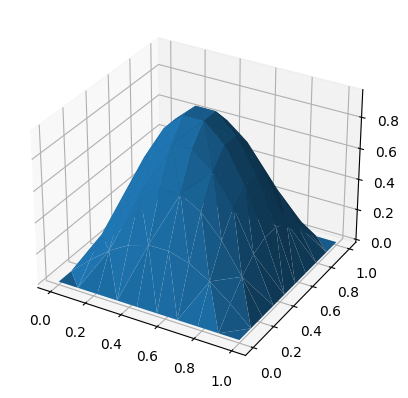

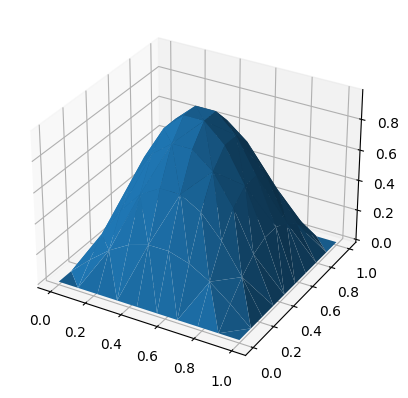

In [ ]:
# Test Partie I
# Solution exacte : u(x,y) = sin(pi*x)*sin(pi*y)
#   => -Delta u = 2*pi^2 * sin(pi*x)*sin(pi*y) = f(x,y)
# CL Dirichlet homogène (u_ex = 0 sur tout le bord)
u_exact = lambda x, y: np.sin(np.pi * x) * np.sin(np.pi * y)
f_test  = lambda x, y: 2 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
ud_test = lambda x, y: 0.0

# Résolution pour n=10
n = 10
coordinates, elements3, dirichlet, neumann = maillage(n)
u_h = resoudre_partie1(coordinates, elements3, dirichlet, f_test, ud_test)

print(f"n={n} : max(|u_h - u_exact|) = {np.max(np.abs(u_h - u_exact(coordinates[:,0], coordinates[:,1]))):.4e}")
show(coordinates, u_h)
show(coordinates, u_exact(coordinates[:,0], coordinates[:,1]))

In [ ]:
# Étude de convergence Partie I
def erreur_L2_triangles(coordinates, elements3, u_h, u_exact_func):
    """Erreur L2 par quadrature au barycentre sur les triangles."""
    err2 = 0.0
    for el in elements3:
        c = coordinates[el]
        x1,y1=c[0]; x2,y2=c[1]; x3,y3=c[2]
        alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        aire = abs(alpha) / 2.0
        xG = (x1+x2+x3)/3.;  yG = (y1+y2+y3)/3.
        u_h_G = np.mean(u_h[el])
        err2 += aire * (u_h_G - u_exact_func(xG, yG))**2
    return np.sqrt(err2)

ns = [4, 8, 16, 32]
errs = []
for n in ns:
    coords, el3, diri, _ = maillage(n)
    u_h = resoudre_partie1(coords, el3, diri, f_test, ud_test)
    e   = erreur_L2_triangles(coords, el3, u_h, u_exact)
    errs.append(e)
    print(f"n={n:3d} | h={1/(n-1):.4f} | erreur L2 = {e:.3e}")

print("\nOrdres de convergence :")
for i in range(1, len(ns)):
    ordre = np.log(errs[i-1]/errs[i]) / np.log((ns[i]-1)/(ns[i-1]-1))
    print(f"  n={ns[i-1]}->{ns[i]} : ordre = {ordre:.2f}")

n=  4 | h=0.3333 | erreur L2 = 1.776e-01
n=  8 | h=0.1429 | erreur L2 = 3.736e-02
n= 16 | h=0.0667 | erreur L2 = 8.347e-03
n= 32 | h=0.0323 | erreur L2 = 1.965e-03

Ordres de convergence :
  n=4->8 : ordre = 1.84
  n=8->16 : ordre = 1.97
  n=16->32 : ordre = 1.99


## Partie II : maillage mixte et ajout des conditions de Neumann

In [ ]:
############################# Maillage mixte ################
e3=np.array([[1,2,12],[2,3,12],[3,4,14],[4,5,14],[2,15,3],[3,15,4]]).astype(int)
e4=np.array([[0,1,12,11],[11,12,13,10],[12,3,14,13],[10,13,8,9],[13,14,7,8],[14,5,6,7]]).astype(int)
dds=np.array([2,15,4,6,7,8,9,10,11,0]).astype(int)
nns=np.array([[4,5],[5,6],[0,1],[1,2]]).astype(int)
ccs=np.array([[0.,0.],[0.33333333333333,0],[0.53333333333333,0.],
                      [0.66666666666667,0.33333333333333],[1.,0.47],[1,0.66666666666667],
                     [1.,1.],[0.66666666666667,1.],[0.33333333333333,1.], [0.,1.],
                     [0.,0.66666666666667],[0.,0.33333333333333],[0.33333333333333,0.33333333333333],
                     [0.33333333333333,0.66666666666667],[0.66666666666667,0.66666666666667],[1.,0.]])

In [ ]:
# 1. Matrice de raideur élémentaire MA_Q pour un quadrangle
# Transformation affine ΦQ : [0,1]^2 -> parallélogramme de sommets (xi,yi) :
#   x = (x2-x1)*xi + (x4-x1)*zeta + x1
#   y = (y2-y1)*xi + (y4-y1)*zeta + y1
#
# Jacobienne J constante (parallélogramme).
# Fonctions de base sur [0,1]^2 :
#   phi1=(1-xi)(1-ze), phi2=xi(1-ze), phi3=xi*ze, phi4=(1-xi)*ze
#
# Formule de changement de variables (annexe) :
#   [MA_Q]_ij = int_[0,1]^2 grad(phi_i)^T (J^T J)^{-1} grad(phi_j) |det J| dxi dze
#
# Calculé par quadrature de Gauss 2x2 (exacte sur ce problème).
#
def mat_raideur_quadrangle(coords):
    """
    Calcule la matrice de raideur élémentaire 4x4 pour un quadrangle (parallélogramme).
    coords : tableau (4,2) des coordonnées des 4 sommets, sens anti-horaire.
    """
    x1,y1 = coords[0];  x2,y2 = coords[1];  x4,y4 = coords[3]

    # Jacobienne de ΦQ (constante)
    J = np.array([[x2-x1, x4-x1],
                  [y2-y1, y4-y1]])
    detJ    = abs(np.linalg.det(J))
    JTJ_inv = np.linalg.inv(J.T @ J)

    # Points et poids de Gauss 2x2 sur [0,1]^2
    g1 = 0.5 - 1.0 / (2.0 * np.sqrt(3.0))
    g2 = 0.5 + 1.0 / (2.0 * np.sqrt(3.0))
    gpts = [g1, g2];  gw = [0.5, 0.5]

    MA_Q = np.zeros((4, 4))
    for xi, wx in zip(gpts, gw):
        for ze, wz in zip(gpts, gw):
            # Gradients des phi_j par rapport à (xi, zeta)
            dphi = np.array([
                [-(1-ze), -(1-xi)],  # phi1 = (1-xi)(1-ze)
                [ (1-ze),  -xi   ],  # phi2 = xi(1-ze)
                [  ze,      xi   ],  # phi3 = xi*ze
                [ -ze,    (1-xi) ],  # phi4 = (1-xi)*ze
            ])  # shape (4,2)
            MA_Q += (dphi @ JTJ_inv @ dphi.T) * detJ * wx * wz

    return MA_Q

In [ ]:
# 2. Assemblage complet (triangles + quadrangles) et second membre avec Neumann
def assembler_A_complet(coordinates, elements3, elements4):
    """Assemble la matrice de raideur globale pour un maillage mixte."""
    N = len(coordinates)
    A = scps.lil_matrix((N, N))

    for el in elements3:
        MA_T = mat_raideur_triangle(coordinates[el])
        for i in range(3):
            for j in range(3):
                A[el[i], el[j]] += MA_T[i, j]

    for el in elements4:
        MA_Q = mat_raideur_quadrangle(coordinates[el])
        for i in range(4):
            for j in range(4):
                A[el[i], el[j]] += MA_Q[i, j]

    return scps.csr_matrix(A)


def assembler_b_complet(coordinates, elements3, elements4, neumann,
                        dirichlet, f, ud, g=None):
    """
    Assemble le second membre pour un maillage mixte avec CL mixtes.

    b_i = int_Omega f*eta_i dx  +  int_{dOmega_N} g*eta_i ds  -  sum_k U_k * A_ik

    Quadrature triangles  : (|alpha|/6) * f(xG,yG)
    Quadrature quadrangles: (|detJ|/4)  * f(xG,yG)
    Quadrature arêtes     : (|arête|/2) * g(milieu)  pour chaque noeud de l'arête
    """
    N = len(coordinates)
    b = np.zeros(N)

    # Valeurs nodales Dirichlet
    U = np.zeros(N)
    for k in np.array(dirichlet).ravel():
        U[k] = ud(coordinates[k, 0], coordinates[k, 1])

    # --- Contribution volumique triangles ---
    for el in elements3:
        c = coordinates[el]
        x1,y1=c[0]; x2,y2=c[1]; x3,y3=c[2]
        alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        xG = (x1+x2+x3)/3.;  yG = (y1+y2+y3)/3.
        contrib = abs(alpha)/6.0 * f(xG, yG)
        for j in range(3):
            b[el[j]] += contrib

    # --- Contribution volumique quadrangles ---
    for el in elements4:
        c = coordinates[el]
        x1,y1=c[0]; x2,y2=c[1]; x4,y4=c[3]
        J    = np.array([[x2-x1, x4-x1],[y2-y1, y4-y1]])
        detJ = abs(np.linalg.det(J))
        xG   = np.mean(c[:,0]);  yG = np.mean(c[:,1])
        contrib = detJ/4.0 * f(xG, yG)
        for j in range(4):
            b[el[j]] += contrib

    # --- Contribution Neumann ---
    # int_{arete} g*eta_i ds ≈ (longueur/2) * g(milieu)  pour chaque noeud de l'arête
    if g is not None and len(neumann) > 0:
        for edge in neumann:
            n1, n2 = edge[0], edge[1]
            xA,yA = coordinates[n1];  xB,yB = coordinates[n2]
            length = np.sqrt((xB-xA)**2 + (yB-yA)**2)
            xM,yM = (xA+xB)/2., (yA+yB)/2.
            gM = g(xM, yM)
            b[n1] += 0.5 * length * gM
            b[n2] += 0.5 * length * gM

    # --- Terme -A * U_d ---
    A = assembler_A_complet(coordinates, elements3, elements4)
    b -= A @ U

    return b, U


def resoudre_partie2(coordinates, elements3, elements4, dirichlet, neumann,
                     f, ud, g=None):
    """Résout -Delta u = f sur le maillage mixte avec CL mixtes."""
    A    = assembler_A_complet(coordinates, elements3, elements4)
    b, U = assembler_b_complet(coordinates, elements3, elements4, neumann,
                                dirichlet, f, ud, g)
    A, b = appliquer_dirichlet(A, b,
                                np.array(dirichlet).reshape(-1,1), U)
    return ssl.spsolve(A, b)

Solution sur le maillage mixte (16 noeuds) :
  noeud  0  (0.000, 0.000)  u = 0.000000
  noeud  1  (0.333, 0.000)  u = 0.040955
  noeud  2  (0.533, 0.000)  u = 0.000000
  noeud  3  (0.667, 0.333)  u = 0.064531
  noeud  4  (1.000, 0.470)  u = 0.000000
  noeud  5  (1.000, 0.667)  u = 0.040389
  noeud  6  (1.000, 1.000)  u = 0.000000
  noeud  7  (0.667, 1.000)  u = 0.000000
  noeud  8  (0.333, 1.000)  u = 0.000000
  noeud  9  (0.000, 1.000)  u = 0.000000
  noeud 10  (0.000, 0.667)  u = 0.000000
  noeud 11  (0.000, 0.333)  u = 0.000000
  noeud 12  (0.333, 0.333)  u = 0.074637
  noeud 13  (0.333, 0.667)  u = 0.068367
  noeud 14  (0.667, 0.667)  u = 0.074437
  noeud 15  (1.000, 0.000)  u = 0.000000


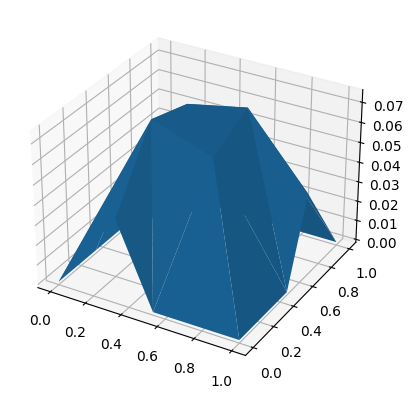

In [ ]:
# 3. Validation sur le maillage mixte fourni
# f=1, ud=0 (Dirichlet homogène sur dds), g=0 sur les arêtes de Neumann (nns)
f_II  = lambda x, y: 1.0
ud_II = lambda x, y: 0.0
g_II  = lambda x, y: 0.0

u_mix = resoudre_partie2(ccs, e3, e4, dds, nns, f_II, ud_II, g_II)

print("Solution sur le maillage mixte (16 noeuds) :")
for k, uk in enumerate(u_mix):
    print(f"  noeud {k:2d}  ({ccs[k,0]:.3f}, {ccs[k,1]:.3f})  u = {uk:.6f}")

show(ccs, u_mix)

## Compléments : un nouveau terme dans l'EDP


In [ ]:
# 4. Matrice de masse élémentaire M̃A_T (triangle)
# Formule exacte pour les intégrales des produits de fonctions de base P1 :
#   int_T eta_i * eta_j dx = aire * (1 + delta_ij) / 12
#
def mat_masse_triangle(coords, c0):
    """
    Matrice de masse élémentaire 3x3 : c0 * int_T eta_i * eta_j dx.
    Formule exacte : aire/12 * (J + I)  où J = matrice de uns.
    """
    x1,y1=coords[0]; x2,y2=coords[1]; x3,y3=coords[2]
    alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
    aire  = abs(alpha) / 2.0
    return c0 * aire / 12.0 * (np.ones((3,3)) + np.eye(3))


# 5. Matrice de masse élémentaire M̃A_Q (quadrangle)
# int_Q eta_i * eta_j dx  = int_[0,1]^2 phi_i(xi,ze)*phi_j(xi,ze) |detJ| dxi dze
# Calculé par quadrature de Gauss 2x2.
#
def mat_masse_quadrangle(coords, c0):
    """
    Matrice de masse élémentaire 4x4 : c0 * int_Q eta_i * eta_j dx.
    Quadrature de Gauss 2x2 sur [0,1]^2.
    """
    x1,y1=coords[0]; x2,y2=coords[1]; x4,y4=coords[3]
    J    = np.array([[x2-x1, x4-x1],[y2-y1, y4-y1]])
    detJ = abs(np.linalg.det(J))

    g1 = 0.5 - 1.0/(2.0*np.sqrt(3.0))
    g2 = 0.5 + 1.0/(2.0*np.sqrt(3.0))
    gpts=[g1,g2];  gw=[0.5, 0.5]

    M = np.zeros((4,4))
    for xi,wx in zip(gpts,gw):
        for ze,wz in zip(gpts,gw):
            phi = np.array([(1-xi)*(1-ze),  xi*(1-ze),  xi*ze,  (1-xi)*ze])
            M  += np.outer(phi, phi) * detJ * wx * wz

    return c0 * M

In [ ]:
# 6 & 7. Assemblage de A = K + c0*M et du second membre (Dirichlet homogène)
def assembler_A_reaction(coordinates, elements3, elements4, c0):
    """Assemble la matrice globale A = K + c0*M pour l'EDP avec réaction."""
    N = len(coordinates)
    A = scps.lil_matrix((N, N))

    for el in elements3:
        local = mat_raideur_triangle(coordinates[el]) \
              + mat_masse_triangle(coordinates[el], c0)
        for i in range(3):
            for j in range(3):
                A[el[i], el[j]] += local[i, j]

    if elements4 is not None and len(elements4) > 0:
        for el in elements4:
            local = mat_raideur_quadrangle(coordinates[el]) \
                  + mat_masse_quadrangle(coordinates[el], c0)
            for i in range(4):
                for j in range(4):
                    A[el[i], el[j]] += local[i, j]

    return scps.csr_matrix(A)


def assembler_b_reaction(coordinates, elements3, elements4, f):
    """Assemble b_i = int_Omega f*eta_i dx (Dirichlet homogène)."""
    N = len(coordinates)
    b = np.zeros(N)

    for el in elements3:
        c = coordinates[el]
        x1,y1=c[0]; x2,y2=c[1]; x3,y3=c[2]
        alpha = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        xG=(x1+x2+x3)/3.;  yG=(y1+y2+y3)/3.
        contrib = abs(alpha)/6.0 * f(xG, yG)
        for j in range(3):
            b[el[j]] += contrib

    if elements4 is not None and len(elements4) > 0:
        for el in elements4:
            c = coordinates[el]
            x1,y1=c[0]; x2,y2=c[1]; x4,y4=c[3]
            J    = np.array([[x2-x1,x4-x1],[y2-y1,y4-y1]])
            detJ = abs(np.linalg.det(J))
            xG=np.mean(c[:,0]);  yG=np.mean(c[:,1])
            contrib = detJ/4.0 * f(xG, yG)
            for j in range(4):
                b[el[j]] += contrib

    return b


def resoudre_reaction(coordinates, elements3, dirichlet, f, c0, elements4=None):
    """Résout -Delta u + c0*u = f avec u=0 sur le bord."""
    A = assembler_A_reaction(coordinates, elements3, elements4, c0)
    b = assembler_b_reaction(coordinates, elements3, elements4, f)
    # Dirichlet homogène
    A = A.tolil()
    for i in np.array(dirichlet).ravel():
        A[i,:]=0;  A[i,i]=1;  b[i]=0.0
    return ssl.spsolve(scps.csr_matrix(A), b)

Erreur max sur maillage mixte (section 2) : 6.5871e-02


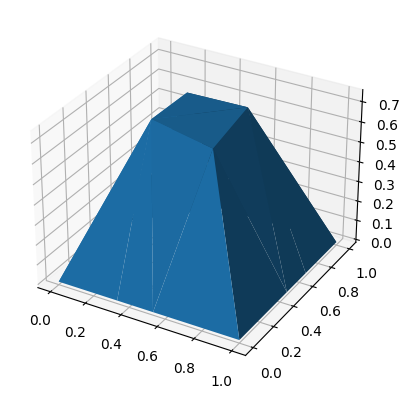

In [ ]:
# 8. Validation sur maillage mixte modifié (Dirichlet homogène partout)
# On utilise le maillage mixte fourni en partie II, avec toute la frontière
# en Dirichlet (suppression de neumann).
# Solution exacte choisie : u = sin(pi*x)*sin(pi*y)
#   => f = (2*pi^2 + c0) * sin(pi*x)*sin(pi*y)

c0   = 1.0
f_r  = lambda x, y: (2*np.pi**2 + c0) * np.sin(np.pi*x) * np.sin(np.pi*y)

# Maillage mixte, tous les noeuds de la frontière en Dirichlet
# (on ajoute les noeuds Neumann nns dans dds)
dds_complet = np.unique(np.concatenate([dds, nns.ravel()]))

u_mix_r = resoudre_reaction(ccs, e3, dds_complet, f_r, c0, elements4=e4)

u_ex_mix = u_exact(ccs[:,0], ccs[:,1])
print(f"Erreur max sur maillage mixte (section 2) : {np.max(np.abs(u_mix_r - u_ex_mix)):.4e}")
show(ccs, u_mix_r)

In [ ]:
# Étude de convergence section 2 (maillage carré, c0 variable)
for c0 in [1.0, 10.0, 100.0]:
    f_r = lambda x, y, c=c0: (2*np.pi**2 + c) * np.sin(np.pi*x) * np.sin(np.pi*y)
    print(f"\nc0 = {c0}")
    errs_r = []
    for n in [4, 8, 16, 32]:
        coords, el3, diri, _ = maillage(n)
        u_h = resoudre_reaction(coords, el3, diri, f_r, c0)
        e   = erreur_L2_triangles(coords, el3, u_h, u_exact)
        errs_r.append(e)
        print(f"  n={n:3d} | erreur L2 = {e:.3e}")
    for i in range(1, 4):
        ns = [4, 8, 16, 32]
        ordre = np.log(errs_r[i-1]/errs_r[i]) / np.log((ns[i]-1)/(ns[i-1]-1))
        print(f"  ordre n={ns[i-1]}->{ns[i]} : {ordre:.2f}")


c0 = 1.0
  n=  4 | erreur L2 = 1.743e-01
  n=  8 | erreur L2 = 3.632e-02
  n= 16 | erreur L2 = 8.100e-03
  n= 32 | erreur L2 = 1.906e-03
  ordre n=4->8 : 1.85
  ordre n=8->16 : 1.97
  ordre n=16->32 : 1.99

c0 = 10.0
  n=  4 | erreur L2 = 1.533e-01
  n=  8 | erreur L2 = 3.010e-02
  n= 16 | erreur L2 = 6.626e-03
  n= 32 | erreur L2 = 1.555e-03
  ordre n=4->8 : 1.92
  ordre n=8->16 : 1.99
  ordre n=16->32 : 2.00

c0 = 100.0
  n=  4 | erreur L2 = 1.113e-01
  n=  8 | erreur L2 = 1.883e-02
  n= 16 | erreur L2 = 4.009e-03
  n= 32 | erreur L2 = 9.336e-04
  ordre n=4->8 : 2.10
  ordre n=8->16 : 2.03
  ordre n=16->32 : 2.01
